In [1]:
import dask
from dask.distributed import Client, wait
from dask import delayed

client = Client()

client

/g/data/xp65/public/apps/med_conda/envs/access-med-0.11/lib/python3.11/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33933 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/33933/status,
Dashboard: /proxy/33933/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44933,Workers: 7
Dashboard: /proxy/33933/status,Total threads: 14
Started: Just now,Total memory: 63.00 GiB
Comm: tcp://127.0.0.1:46125,Total threads: 2
Dashboard: /proxy/41717/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:41451,


In [2]:
#import all the stuff
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib
#import xclim.indices
from datetime import timedelta
import cartopy.crs as ccrs
import cartopy as cart
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import glob

In [4]:
#Set parameters
CMIP='CMIP6'
#AGENCY = 'CSIRO' 
#RCM = 'CCAM-v2203-SN'
AGENCY = 'BOM' 
RCM = 'BARPA-R'

GCM = 'ACCESS-ESM1-5' 
ensemble = 'r6i1p1f1' #Done
#GCM = 'ACCESS-CM2' #ensemble = 'r4i1p1f1' #Done
#GCM = 'CESM2' #ensemble = 'r11i1p1f1' #Done

#GCM = 'CNRM-ESM2-1' #ensemble = 'r1i1p1f2' #CSIRO Done, no BOM

#GCM = 'MPI-ESM1-2-HR' #ensemble = 'r1i1p1f1' #BOM done, no CSIRO

#GCM = 'EC-Earth3' #ensemble = 'r1i1p1f1' #Done

#GCM = 'NorESM2-MM' #Done
#ensemble = 'r1i1p1f1'


#GCM = 'CMCC-ESM2'
#ensemble = 'r1i1p1f1'

#GCM = 'CESM2'
#ensemble = 'r11i1p1f1'

#pathway = 'ssp126'
pathway = 'ssp370'

#data_dir = '/g/data/ia39/ncra/bushfire/vpd/'
#data_dir_mm = '/g/data/ia39/ncra/bushfire/vpd/monthly_mean/'

In [5]:
#infiles12=f"/g/data/ia39/ncra/bushfire/vpd/{GCM}/{pathway}/{ensemble}/{RCM}/v1-r1/day/{pathway}_{GCM}_{RCM}_gwl1.2_vpd.nc"
#vpd_data_12 = xr.open_dataset(infiles12)['vpd']
#infiles15=f"/g/data/ia39/ncra/bushfire/vpd/{GCM}/{pathway}/{ensemble}/{RCM}/v1-r1/day/{pathway}_{GCM}_{RCM}_gwl1.5_vpd.nc"
#vpd_data_15 = xr.open_dataset(infiles15)['vpd']
#infiles20=f"/g/data/ia39/ncra/bushfire/vpd/{GCM}/{pathway}/{ensemble}/{RCM}/v1-r1/day/{pathway}_{GCM}_{RCM}_gwl2.0_vpd.nc"
#vpd_data_20 = xr.open_dataset(infiles20)['vpd']
#infiles30=f"/g/data/ia39/ncra/bushfire/vpd/{GCM}/{pathway}/{ensemble}/{RCM}/v1-r1/day/{pathway}_{GCM}_{RCM}_gwl3.0_vpd.nc"
#vpd_data_30 = xr.open_dataset(infiles30)['vpd']

Bring in all the thresholded files, these have the total counts. Need to divide by 20 to get the yearly average

In [6]:
infiles12=f"/g/data/ia39/ncra/bushfire/vpd/threshold18/{pathway}_{GCM}_{RCM}_gwl1.2_vpd_days_gt_18.nc"
thresh18_vpd_data_12 = xr.open_dataset(infiles12)['vpd']/20
infiles15=f"/g/data/ia39/ncra/bushfire/vpd/threshold18/{pathway}_{GCM}_{RCM}_gwl1.5_vpd_days_gt_18.nc"
thresh18_vpd_data_15 = xr.open_dataset(infiles15)['vpd']/20
infiles20=f"/g/data/ia39/ncra/bushfire/vpd/threshold18/{pathway}_{GCM}_{RCM}_gwl2.0_vpd_days_gt_18.nc"
thresh18_vpd_data_20 = xr.open_dataset(infiles20)['vpd']/20
infiles30=f"/g/data/ia39/ncra/bushfire/vpd/threshold18/{pathway}_{GCM}_{RCM}_gwl3.0_vpd_days_gt_18.nc"
thresh18_vpd_data_30 = xr.open_dataset(infiles30)['vpd']/20

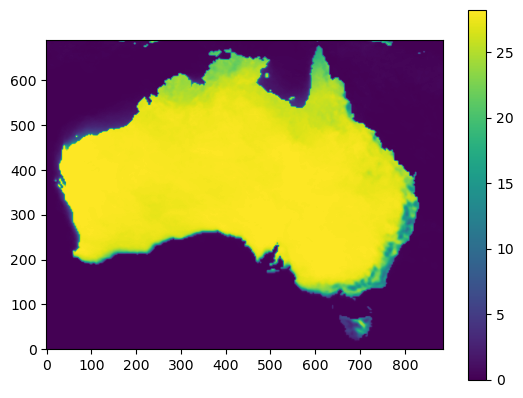

In [7]:
plt.imshow(thresh18_vpd_data_30[1], origin='lower')
plt.colorbar()

In [8]:
#convert lat/lon to an index:
#loc_name = 'Adelaide'
#lat = -34.95 #Adelaide
#lon = 138.60 #Adelaide

#loc_name = 'Dandenongs'
#lat = -37.8335 #Dandenongs
#lon = 145.3501 #Dandenongs

loc_name = 'Canberra'
lat = -35.2802
lon = 149.1310

#loc_name = 'Manjimup'
#lat = -34.2432
#lon = 116.1453

#loc_name = 'Cradle Mountain'
#lat = -41.6800
#lon = 145.9400

#loc_name = 'Kosciuszko'
#lat = -36.4559
#lon = 148.2636


lat_ind = round((lat + 44.5)/0.05)
lon_ind = round((lon - 112)/0.05)


gwl12_monthly_vpd_count = thresh18_vpd_data_12.isel(lat = lat_ind, lon = lon_ind)
gwl15_monthly_vpd_count = thresh18_vpd_data_15.isel(lat = lat_ind, lon = lon_ind)
gwl20_monthly_vpd_count = thresh18_vpd_data_20.isel(lat = lat_ind, lon = lon_ind)
gwl30_monthly_vpd_count = thresh18_vpd_data_30.isel(lat = lat_ind, lon = lon_ind)

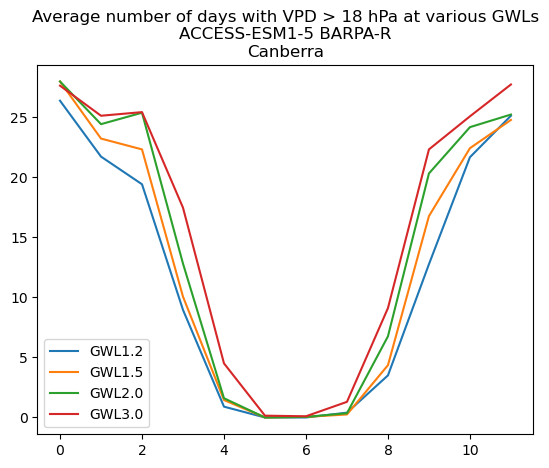

In [9]:
#%%time
plt.plot(gwl12_monthly_vpd_count, label = "GWL1.2")
plt.plot(gwl15_monthly_vpd_count, label = "GWL1.5")
plt.plot(gwl20_monthly_vpd_count, label = "GWL2.0")
plt.plot(gwl30_monthly_vpd_count, label = "GWL3.0")
plt.legend()
plt.title('Average number of days with VPD > 18 hPa at various GWLs\n%s %s\n%s' %(GCM, RCM, loc_name))
plt.show()

Weird stuff in EC-Earth3_BARPA-R (zeros for all months for Canberra at GWL3)

In [141]:
#mean_vpd_data = xr.open_dataset("/g/data/ia39/ncra/bushfire/vpd/monthly_mean/gwl3.0_monthly_mean_vpd_EC-Earth3_BARPA-R_ssp370_r1i1p1f1.nc")['monthly_mean_vpd']
days_over_18 = xr.open_dataset("/g/data/ia39/ncra/bushfire/vpd/threshold18/ssp370_EC-Earth3_BARPA-R_gwl3.0_vpd_days_gt_18.nc")['vpd']/20
#test = xr.open_dataset("/g/data/ia39/ncra/bushfire/vpd/EC-Earth3/ssp370/r1i1p1f1/BARPA-R/v1-r1/day/ssp370_EC-Earth3_BARPA-R_gwl3.0_vpd.nc")['vpd']

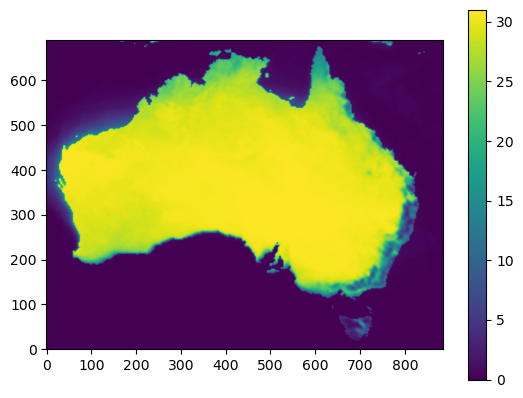

In [146]:
plt.imshow(days_over_18[2], origin='lower')
plt.colorbar()

In [12]:
mean_vpd_data

<xarray.DataArray 'monthly_mean_vpd' (month: 12, lat: 691, lon: 886)> Size: 29MB
[7346712 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 6kB -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon      (lon) float64 7kB 112.0 112.0 112.1 112.2 ... 156.2 156.2 156.2
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    long_name:      Monthly mean vapour dressure deficit computed from tasmax...
    standard_name:  monthly_mean_vpd
    units:          hPa

In [27]:
AGENCY = 'CSIRO' 
RCM = 'CCAM-v2203-SN'

#AGENCY = 'BOM' 
#RCM = 'BARPA-R'

GCM = 'ACCESS-ESM1-5' 
ensemble = 'r6i1p1f1' #Done
pathway = 'ssp370'

file30_name = '/g/data/ia39/ncra/bushfire/vpd/monthly_mean/gwl3.0_monthly_mean_vpd_' + GCM + '_' + RCM + '_' + pathway + '_' + ensemble + '.nc' 
file20_name = '/g/data/ia39/ncra/bushfire/vpd/monthly_mean/gwl2.0_monthly_mean_vpd_' + GCM + '_' + RCM + '_' + pathway + '_' + ensemble + '.nc' 
file15_name = '/g/data/ia39/ncra/bushfire/vpd/monthly_mean/gwl1.5_monthly_mean_vpd_' + GCM + '_' + RCM + '_' + pathway + '_' + ensemble + '.nc' 
file12_name = '/g/data/ia39/ncra/bushfire/vpd/monthly_mean/gwl1.2_monthly_mean_vpd_' + GCM + '_' + RCM + '_' + pathway + '_' + ensemble + '.nc' 

gwl30_mean_vpr_data = xr.open_dataset(file30_name)['monthly_mean_vpd']
gwl20_mean_vpr_data = xr.open_dataset(file20_name)['monthly_mean_vpd']
gwl15_mean_vpr_data = xr.open_dataset(file15_name)['monthly_mean_vpd']
gwl12_mean_vpr_data = xr.open_dataset(file12_name)['monthly_mean_vpd']



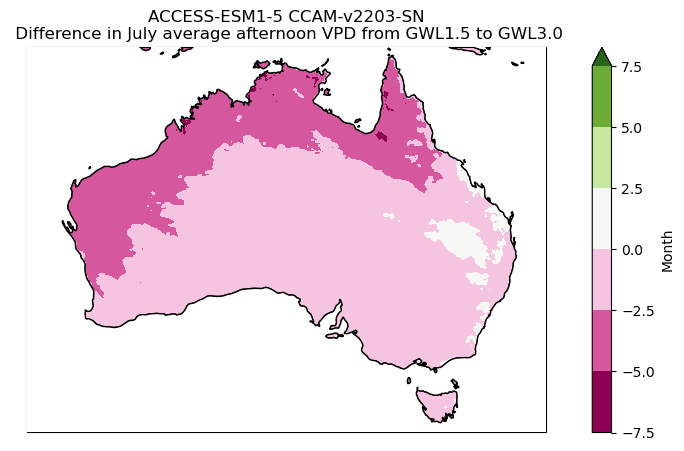

In [29]:
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
m = 6

fig = plt.figure(figsize=[12,5])
ax = fig.add_subplot(111, projection=ccrs.PlateCarree(central_longitude=180))

(gwl15_mean_vpr_data[m] - gwl30_mean_vpr_data[m]).plot.contourf(ax=ax,
                  extend='max',
                  transform=ccrs.PlateCarree(),
                  cbar_kwargs={'label': 'Month'},
                  cmap='PiYG'
                  )

month = months[m]
ax.coastlines()
ax.add_feature(cart.feature.OCEAN, zorder=100, edgecolor='black', facecolor='white')
title = '%s %s\n Difference in %s average afternoon VPD from GWL1.5 to GWL3.0' %(GCM, RCM, month)
ax.set_title(title)

plt.show()

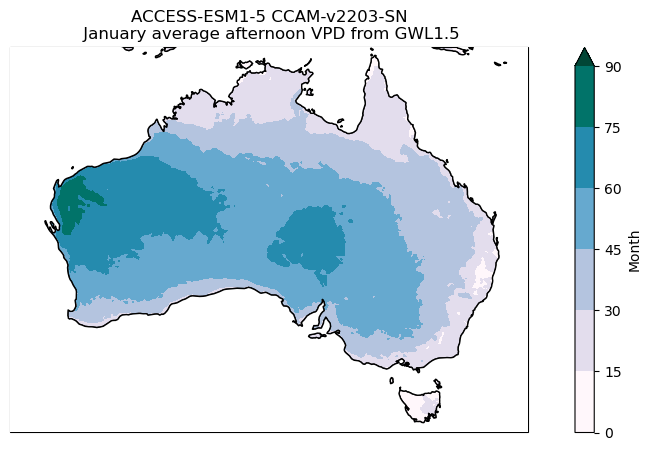

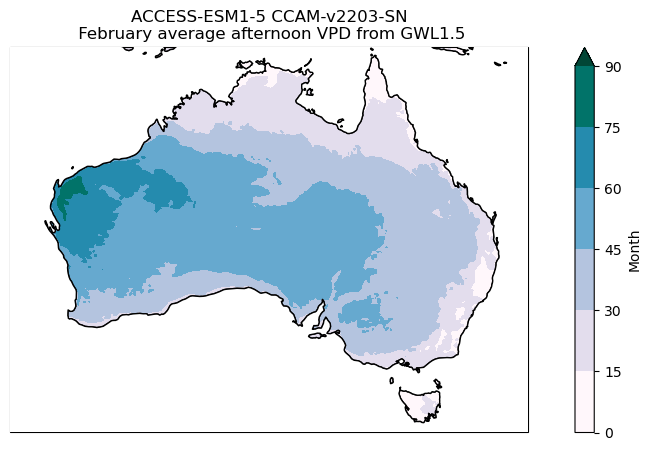

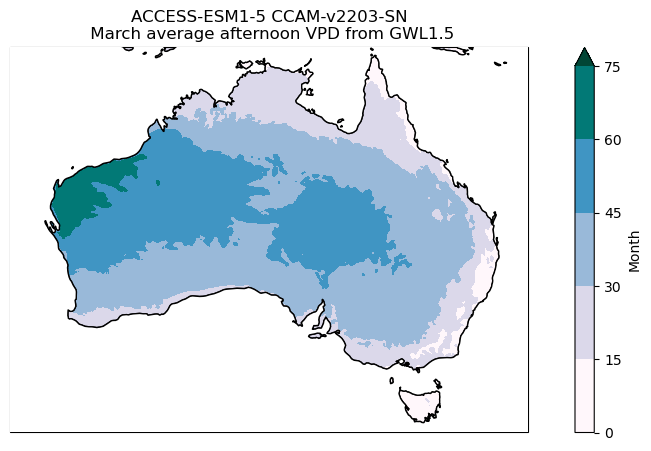

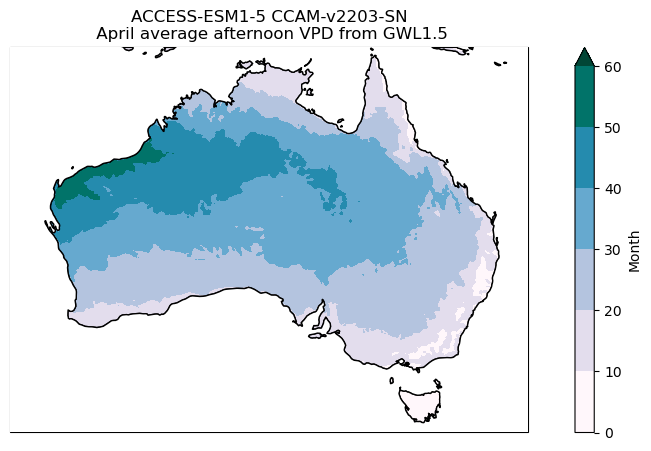

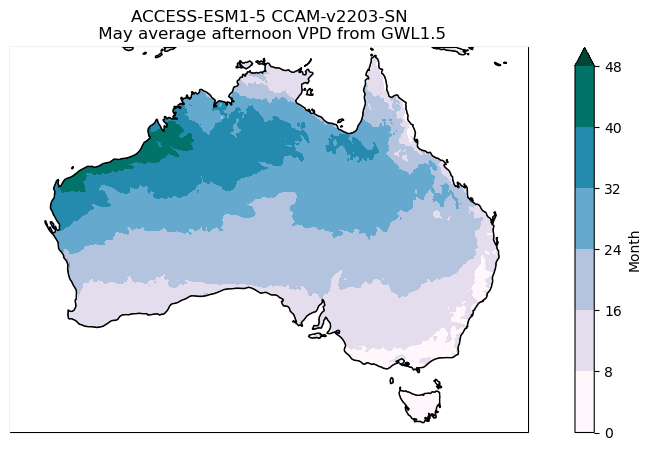

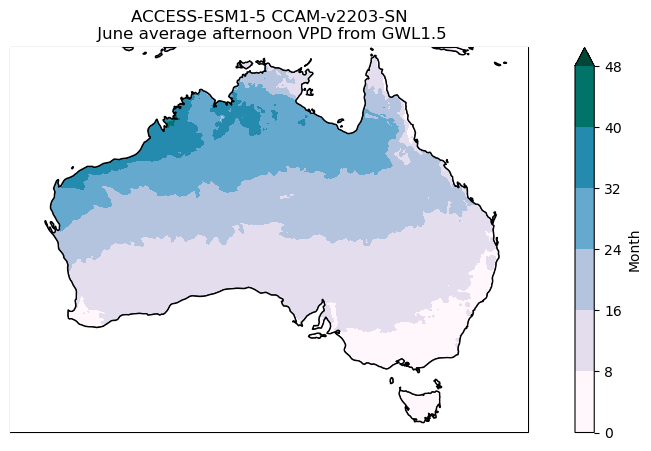

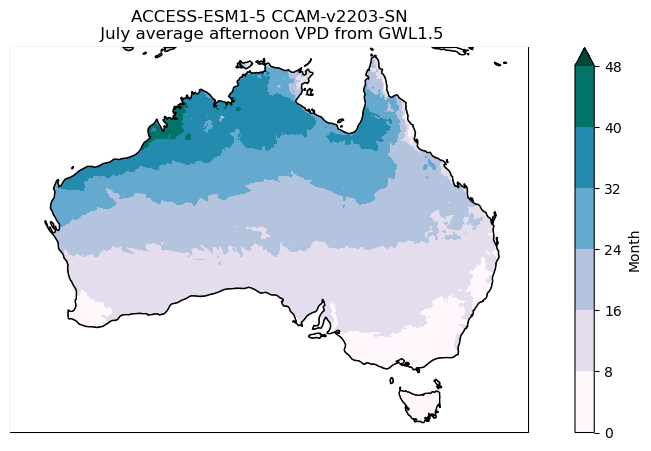

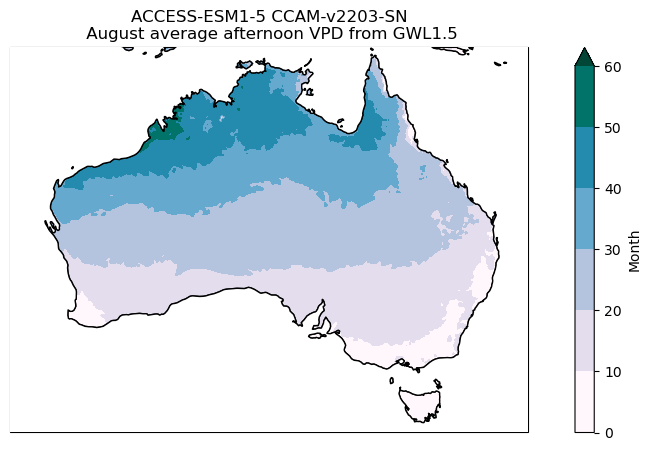

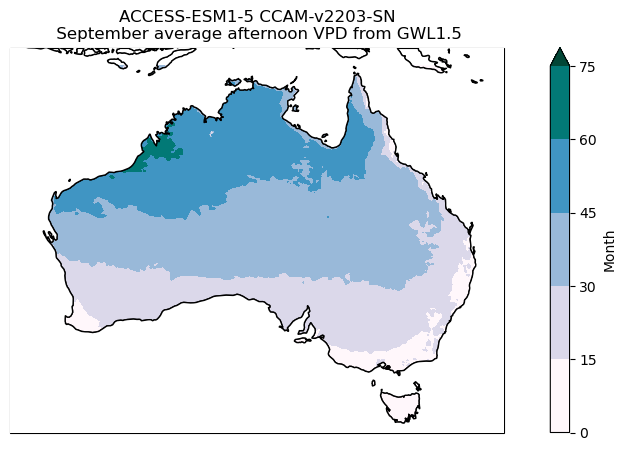

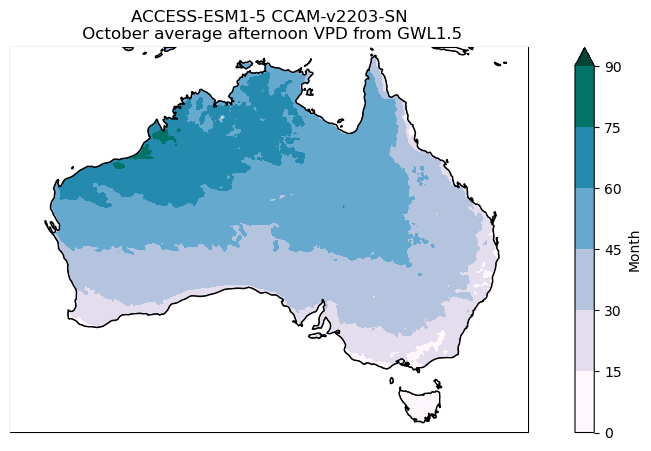

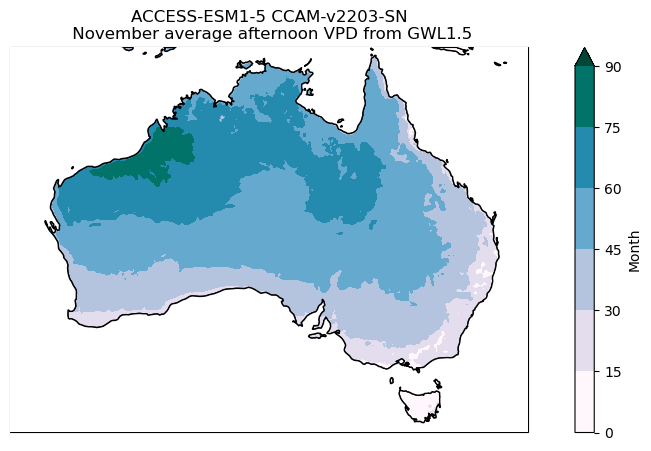

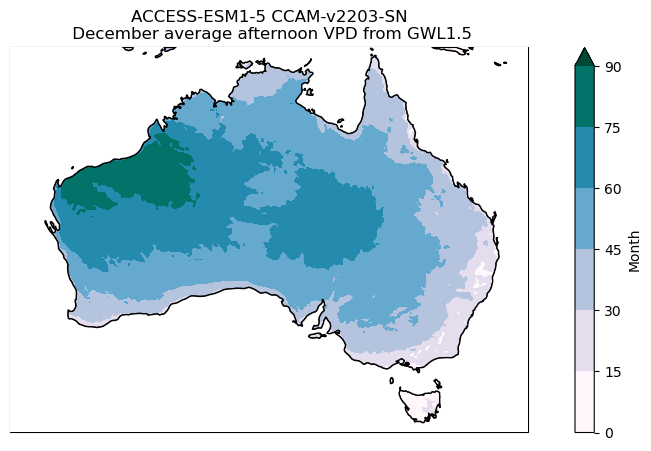

In [6]:
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
m = 0
for m in range(12):

    fig = plt.figure(figsize=[12,5])
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree(central_longitude=180))

    (gwl15_mean_vpr_data[m]).plot.contourf(ax=ax,
                      extend='max',
                      transform=ccrs.PlateCarree(),
                      cbar_kwargs={'label': 'Month'},
                      cmap='PuBuGn'
                      )

    month = months[m]
    ax.coastlines()
    ax.add_feature(cart.feature.OCEAN, zorder=100, edgecolor='black', facecolor='white')
    title = '%s %s\n %s average afternoon VPD from GWL1.5' %(GCM, RCM, month)
    ax.set_title(title)

    plt.show()

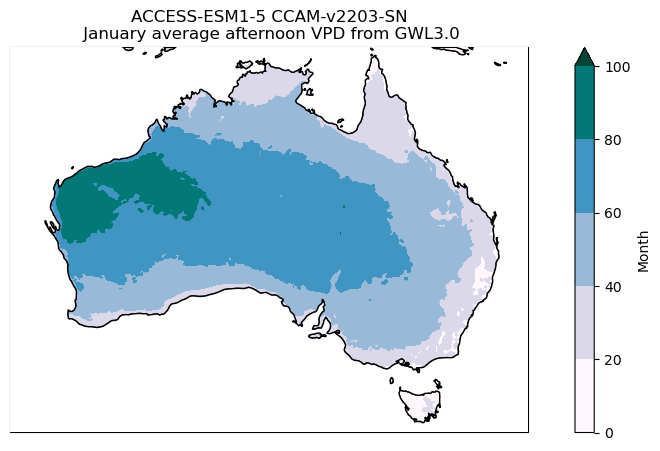

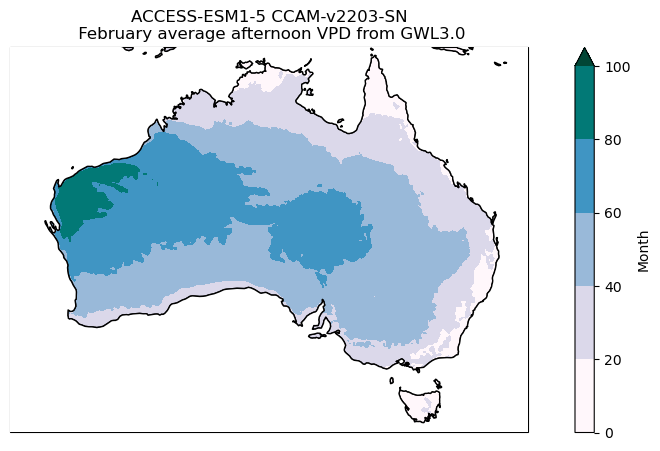

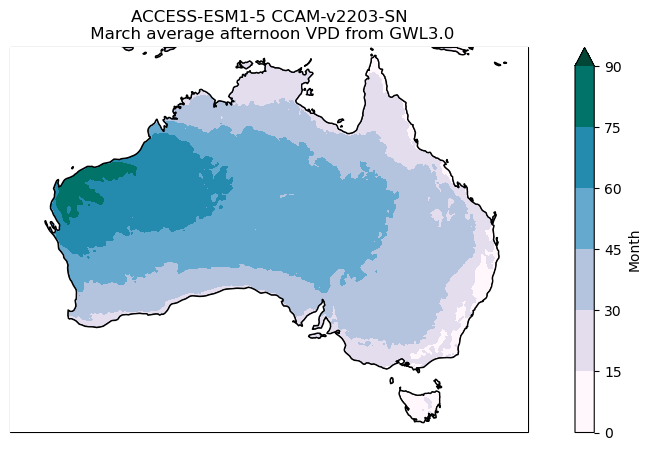

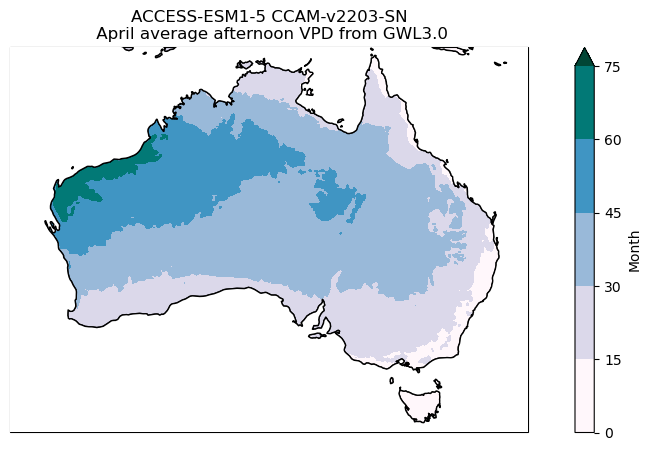

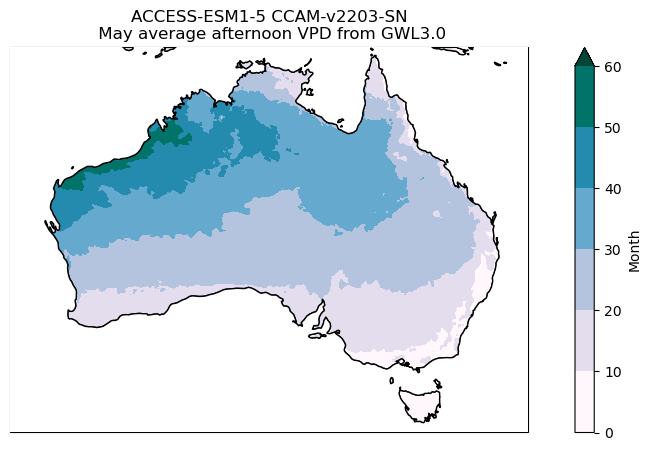

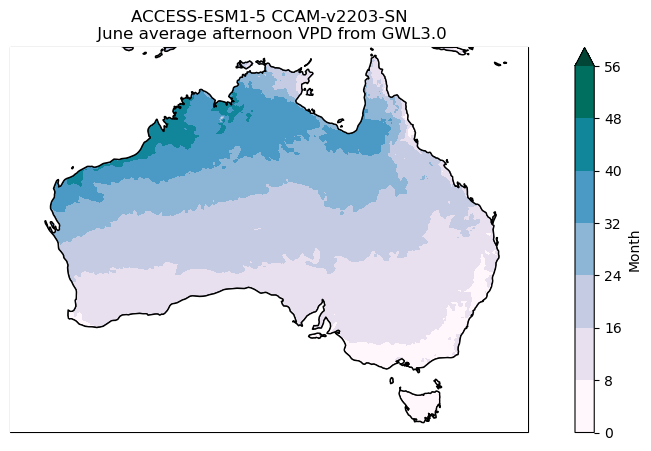

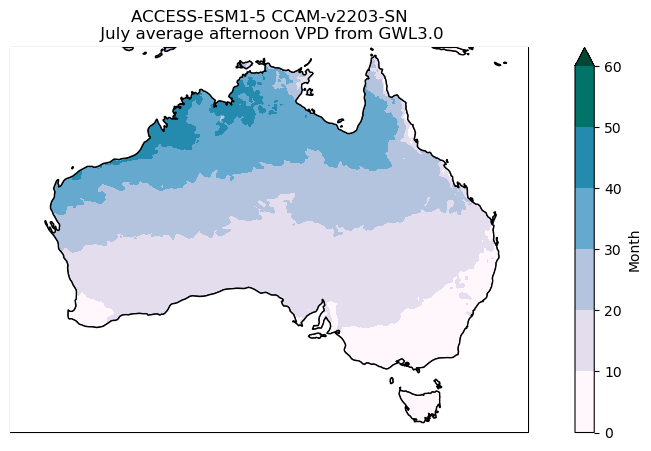

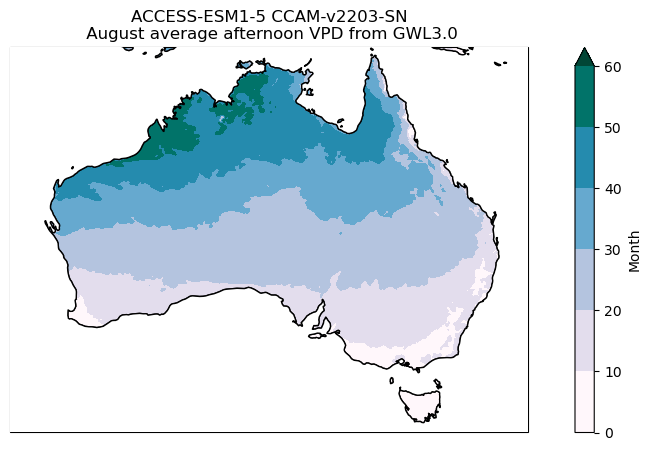

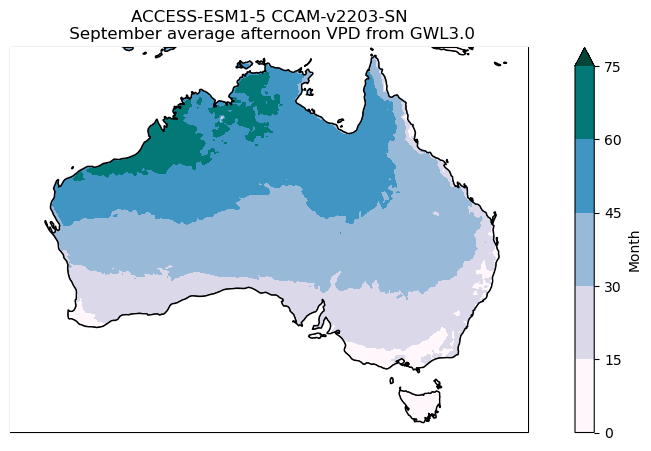

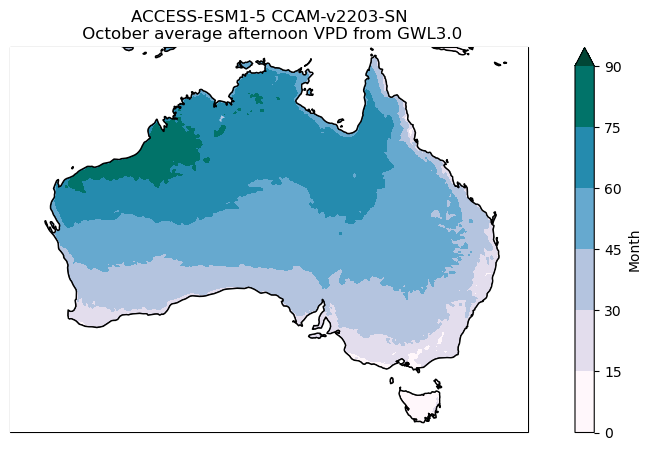

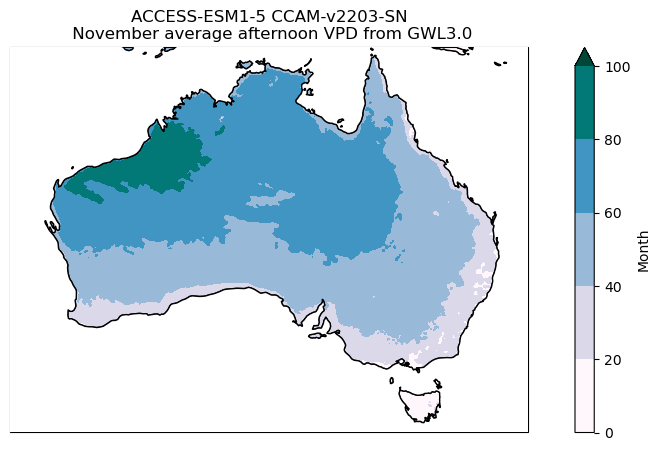

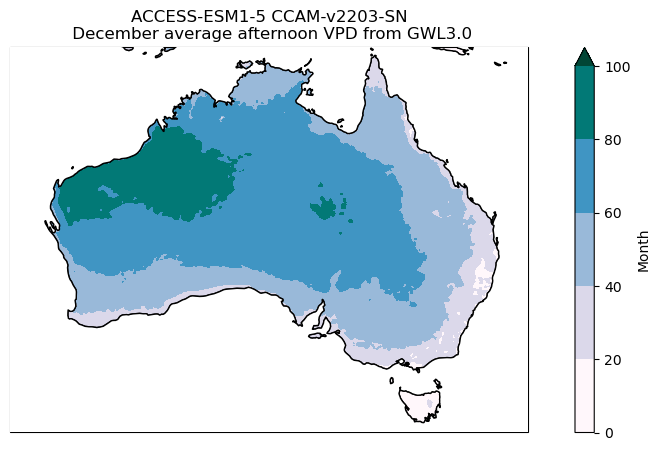

In [49]:
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
m = 0
for m in range(12):

    fig = plt.figure(figsize=[12,5])
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree(central_longitude=180))

    (gwl30_mean_vpr_data[m]).plot.contourf(ax=ax,
                      extend='max',
                      transform=ccrs.PlateCarree(),
                      cbar_kwargs={'label': 'Month'},
                      cmap='PuBuGn'
                      )

    month = months[m]
    ax.coastlines()
    ax.add_feature(cart.feature.OCEAN, zorder=100, edgecolor='black', facecolor='white')
    title = '%s %s\n %s average afternoon VPD from GWL3.0' %(GCM, RCM, month)
    ax.set_title(title)

    plt.show()

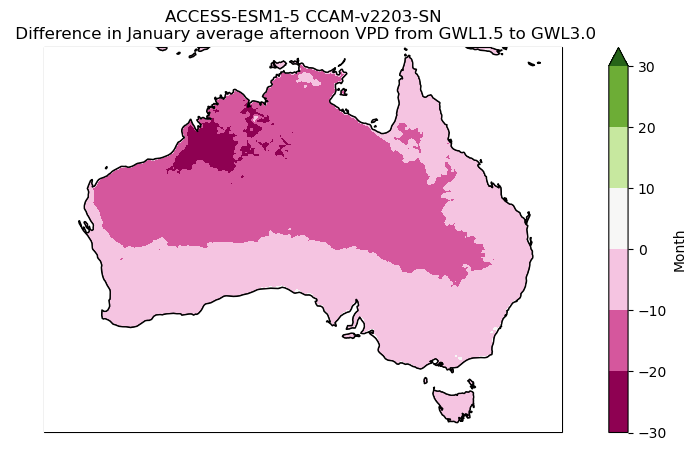

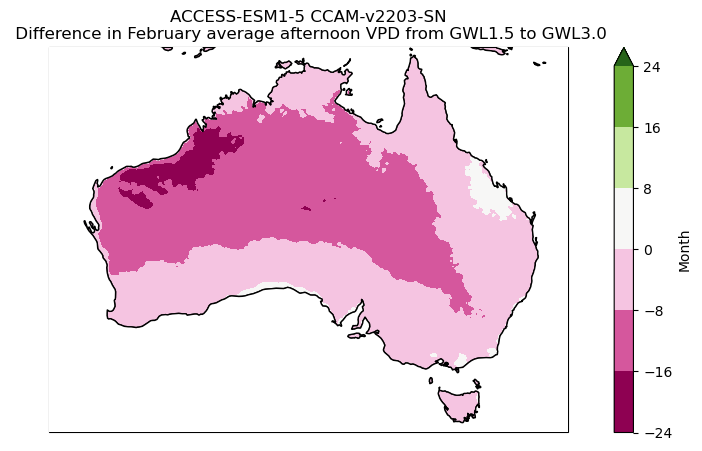

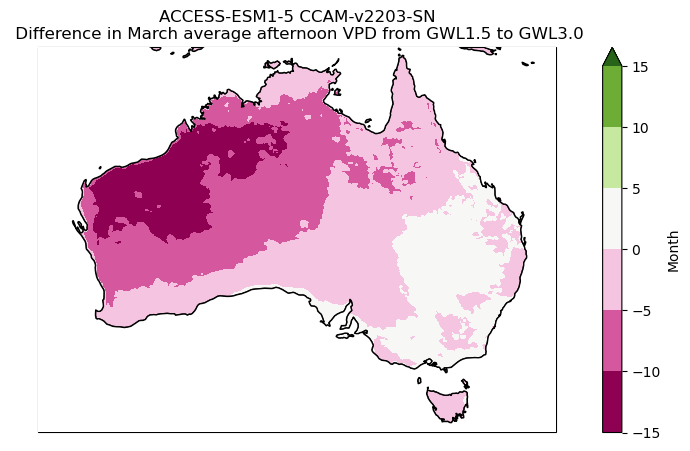

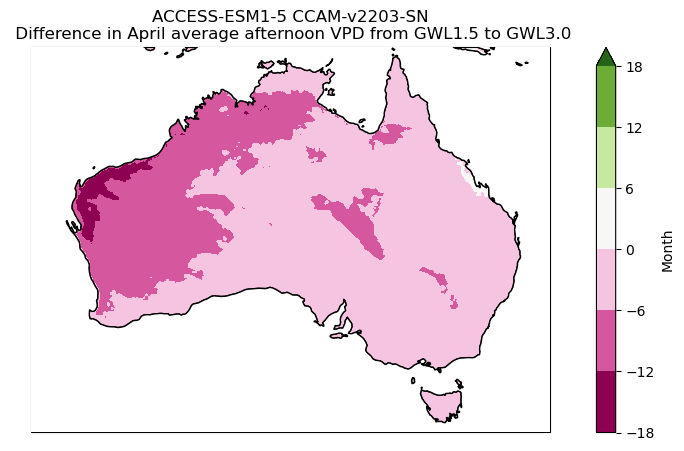

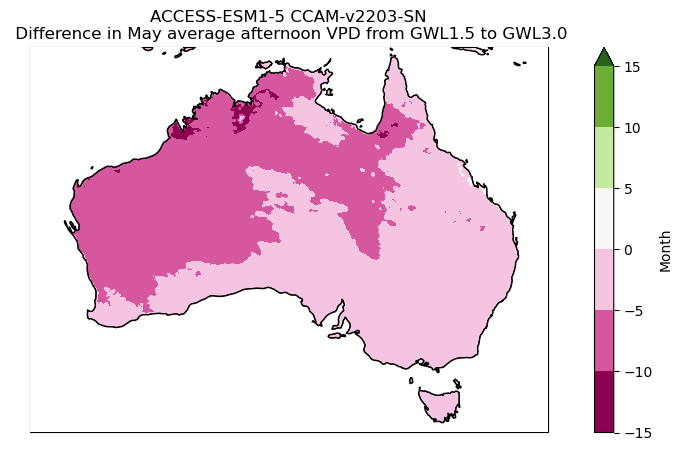

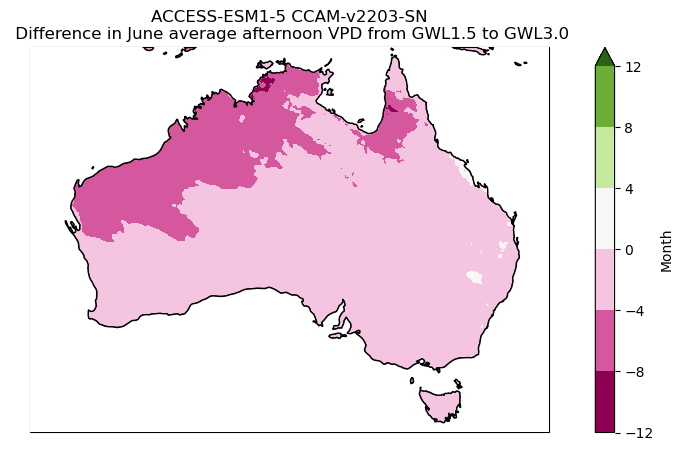

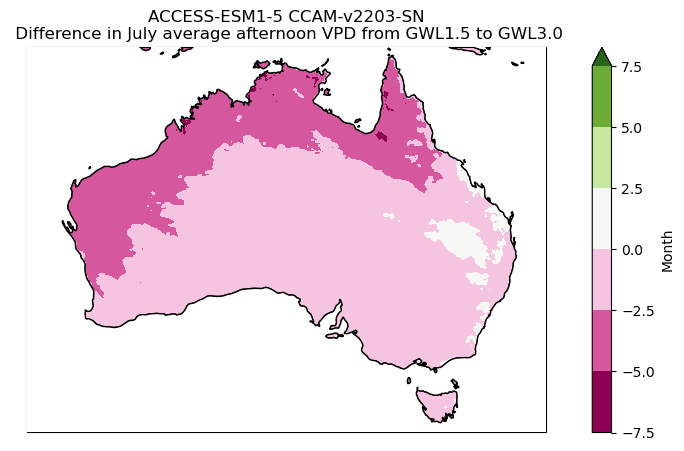

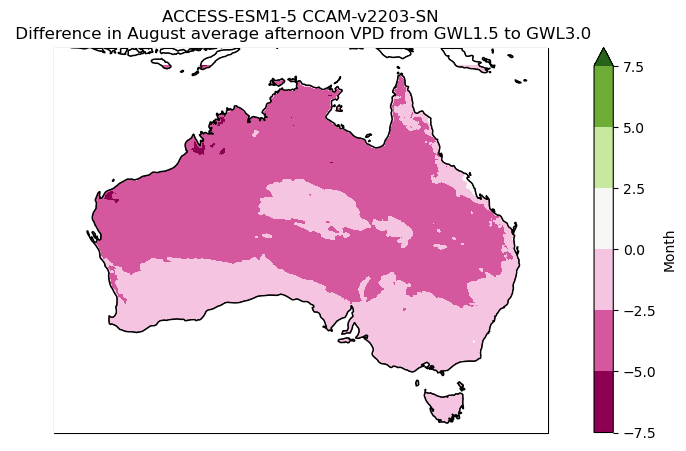

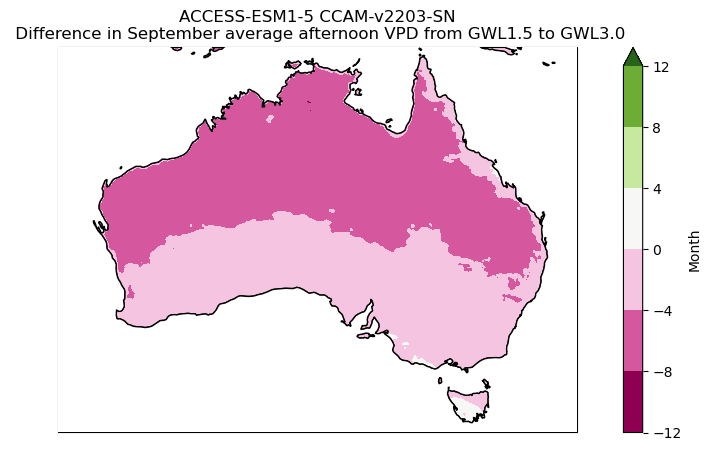

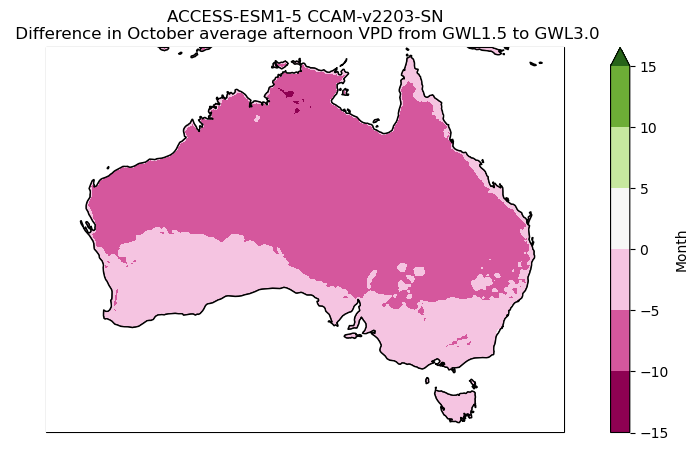

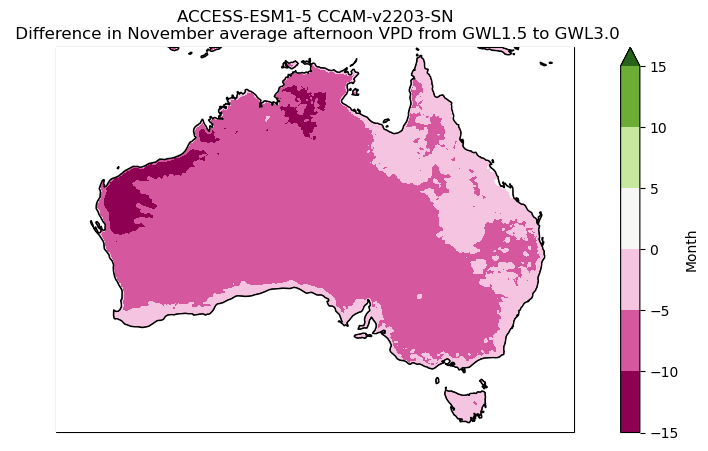

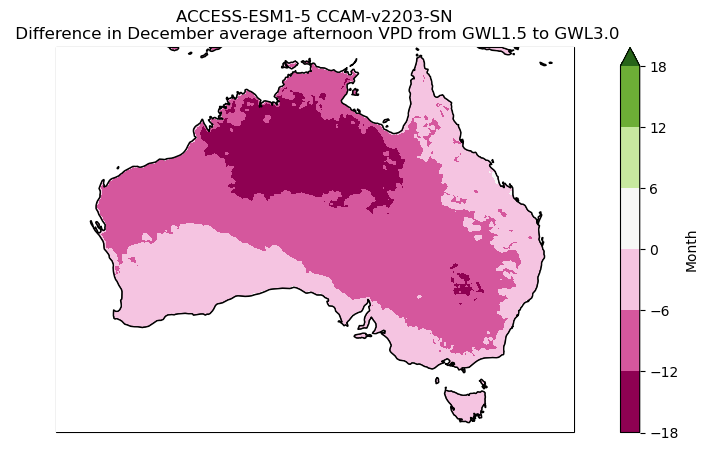

In [8]:
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

for m in range(12):
    fig = plt.figure(figsize=[12,5])
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree(central_longitude=180))

    (gwl15_mean_vpr_data[m] - gwl30_mean_vpr_data[m]).plot.contourf(ax=ax,
                      extend='max',
                      transform=ccrs.PlateCarree(),
                      cbar_kwargs={'label': 'Month'},
                      cmap='PiYG'
                      )

    month = months[m]
    ax.coastlines()
    ax.add_feature(cart.feature.OCEAN, zorder=100, edgecolor='black', facecolor='white')
    title = '%s %s\n Difference in %s average afternoon VPD from GWL1.5 to GWL3.0' %(GCM, RCM, month)
    ax.set_title(title)

    plt.show()

In [30]:
cd /g/data/mn51/users/gt3409/plotting_maps/

/g/data/mn51/users/gt3409/plotting_maps


In [31]:
%%time
from acs_plotting_maps import *
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib import colors, cm

CPU times: user 7.24 s, sys: 731 ms, total: 7.98 s
Wall time: 9.68 s


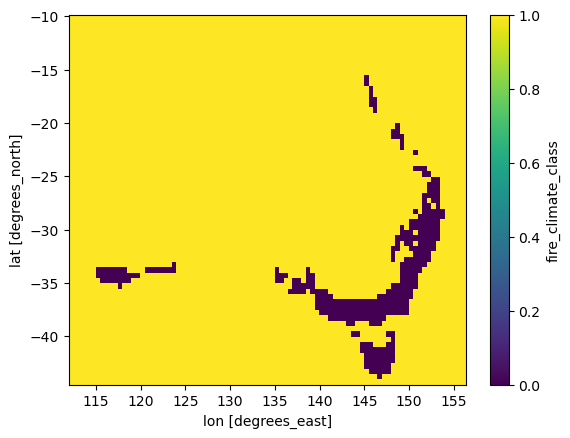

In [32]:
forest_area = xr.open_dataset("/g/data/ai05/ae2105/climate_classifications/fire_classes/fire_climate_classes_AGCDv1_1991-2020.nc")
shading = (((forest_area["fire_climate_class"]==102) + (forest_area["fire_climate_class"]==103)).coarsen(lat=10, boundary="pad").mean().coarsen(lon=10, boundary="pad").mean()<0.1)
shading.plot()

PermissionError: [Errno 13] Permission denied: '/g/data/mn51/users/gt3409/plotting_maps/figures/.png.png'

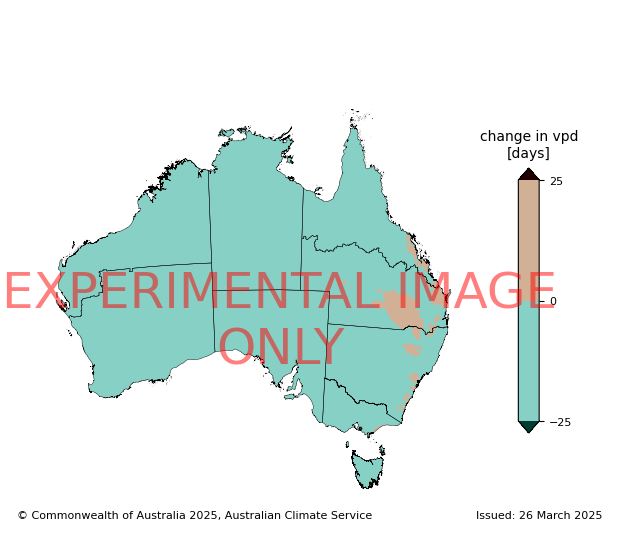

In [47]:
%%time
# Masked VPD maps 
m = 6

ticks_future=np.arange(-25, 26, 25)
cmap_future=cmap_dict["aridity_anom_r"]
label_future=f"change in vpd\n[days]"

ds_gwl = gwl15_mean_vpr_data[m] - gwl30_mean_vpr_data[m]

plot_acs_hazard_1pp(data=ds_gwl,
                    title="",
                    #regions = regions,
                    #agcd_mask=True,
                    shading=shading,
                    cmap = cmap_future,
                    ticks = ticks_future,
                    cbar_label = label_future,
                    #watermark=watermark,
                    #issued_date=issued_date,
                    #outfile=f"figures/holistic-australian-bushfire-risk-assessment/{var}_gwl30.png"
                    )